# EDA: Time-MMD 통합 데이터 (Monthly 5개 도메인)

`data/processed/{Agriculture,Economy,Security,SocialGood,Traffic}_merged.csv` 분석.

**목적**
1. 도메인별 시계열 패턴 시각화 (OT 및 다변량)
2. 텍스트 sparsity 시간 변화 / length 분포
3. OT 결측 패턴
4. Cross-domain 비교 (정규화 후 overlay) — Phase 2 파일럿의 도메인 페어 선정 참고

설계 문서: `MD_files/02_dataset_design.md`

## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams['figure.dpi'] = 100
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

DATA_DIR = Path('../data/processed')
DOMAINS = ['Agriculture', 'Economy', 'Security', 'SocialGood', 'Traffic']

TEXT_COLS = ['report_text', 'search_text', 'report_pred', 'search_pred']
META_TEXT_COLS = ['date', 'start_date', 'end_date'] + TEXT_COLS

def var_cols(df):
    return [c for c in df.columns if c not in META_TEXT_COLS]

In [2]:
dfs = {}
for d in DOMAINS:
    df = pd.read_csv(DATA_DIR / f'{d}_merged.csv',
                     parse_dates=['date', 'start_date', 'end_date'])
    dfs[d] = df
    print(f'{d:12s}: shape={df.shape}, '
          f'range={df.date.min().date()} ~ {df.date.max().date()}, '
          f'vars={var_cols(df)}')

Agriculture : shape=(408, 10), range=1990-01-01 ~ 2023-12-01, vars=['Wholesale broiler composite', 'OT', 'Retail-wholesale spread for broiler composite']
Economy     : shape=(447, 10), range=1987-01-01 ~ 2024-03-01, vars=['Exports', 'Imports', 'OT']
Security    : shape=(309, 8), range=1998-09-01 ~ 2024-05-01, vars=['OT']
SocialGood  : shape=(916, 8), range=1948-01-01 ~ 2024-04-01, vars=['OT']
Traffic     : shape=(651, 8), range=1970-01-01 ~ 2024-03-01, vars=['OT']


## 1. Summary Table

In [3]:
rows = []
for d, df in dfs.items():
    rows.append({
        'domain': d,
        'rows': len(df),
        'start': df.date.min().date(),
        'end': df.date.max().date(),
        'n_vars': len(var_cols(df)),
        'OT_nan': int(df['OT'].isna().sum()),
        'report_noinfo_%': round((df.report_text == 'No information').mean() * 100, 1),
        'search_noinfo_%': round((df.search_text == 'No information').mean() * 100, 1),
    })
summary = pd.DataFrame(rows).set_index('domain')
summary

,rows,start,end,n_vars,OT_nan,report_noinfo_%,search_noinfo_%
domain,,,,,,,
Agriculture,408,1990-01-01,2023-12-01,3,0,87.3,11.5
Economy,447,1987-01-01,2024-03-01,3,0,22.8,0.0
Security,309,1998-09-01,2024-05-01,1,0,100.0,0.0
SocialGood,916,1948-01-01,2024-04-01,1,0,63.1,41.9
Traffic,651,1970-01-01,2024-03-01,1,0,59.0,18.4


## 2. OT Time Series (per domain)

5개 도메인의 target variable (OT) 시간 변화. 스케일이 다 다르므로 도메인별 subplot.

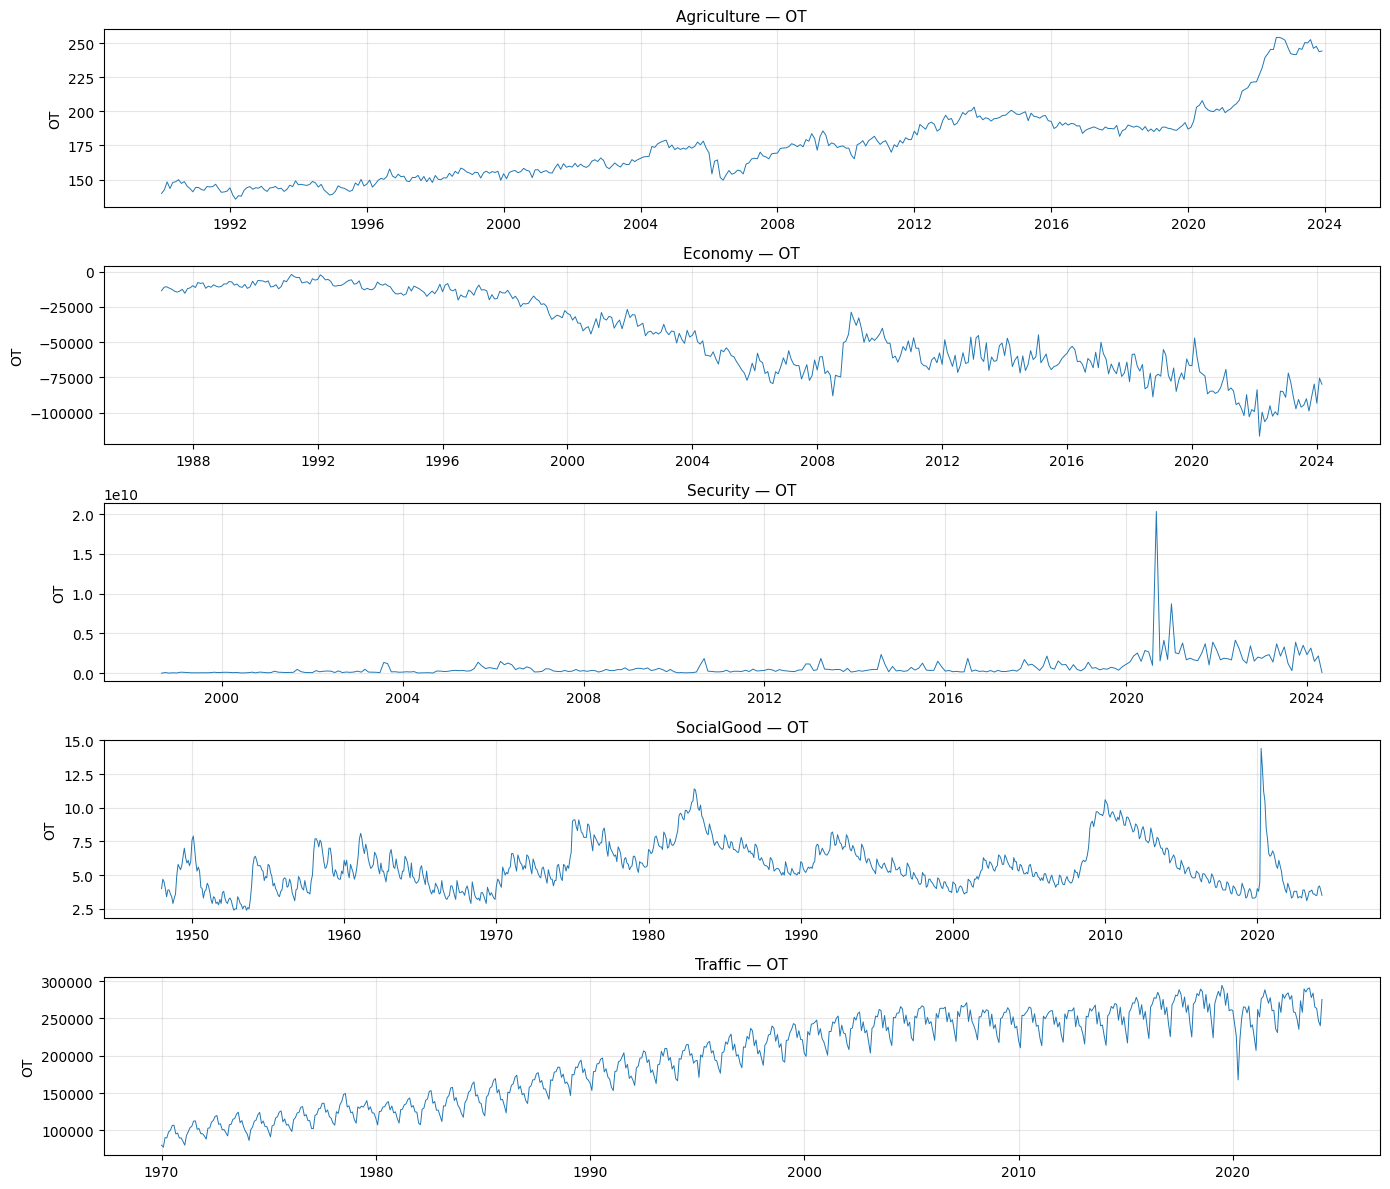

In [4]:
fig, axes = plt.subplots(5, 1, figsize=(14, 12), sharex=False)
for ax, (d, df) in zip(axes, dfs.items()):
    ax.plot(df.date, df['OT'], linewidth=0.7)
    ax.set_title(f'{d} — OT', fontsize=11)
    ax.set_ylabel('OT')
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Multivariate Variables (Agriculture, Economy)

Agriculture/Economy는 OT 외 추가 변수가 있음. 다른 3개는 OT만.

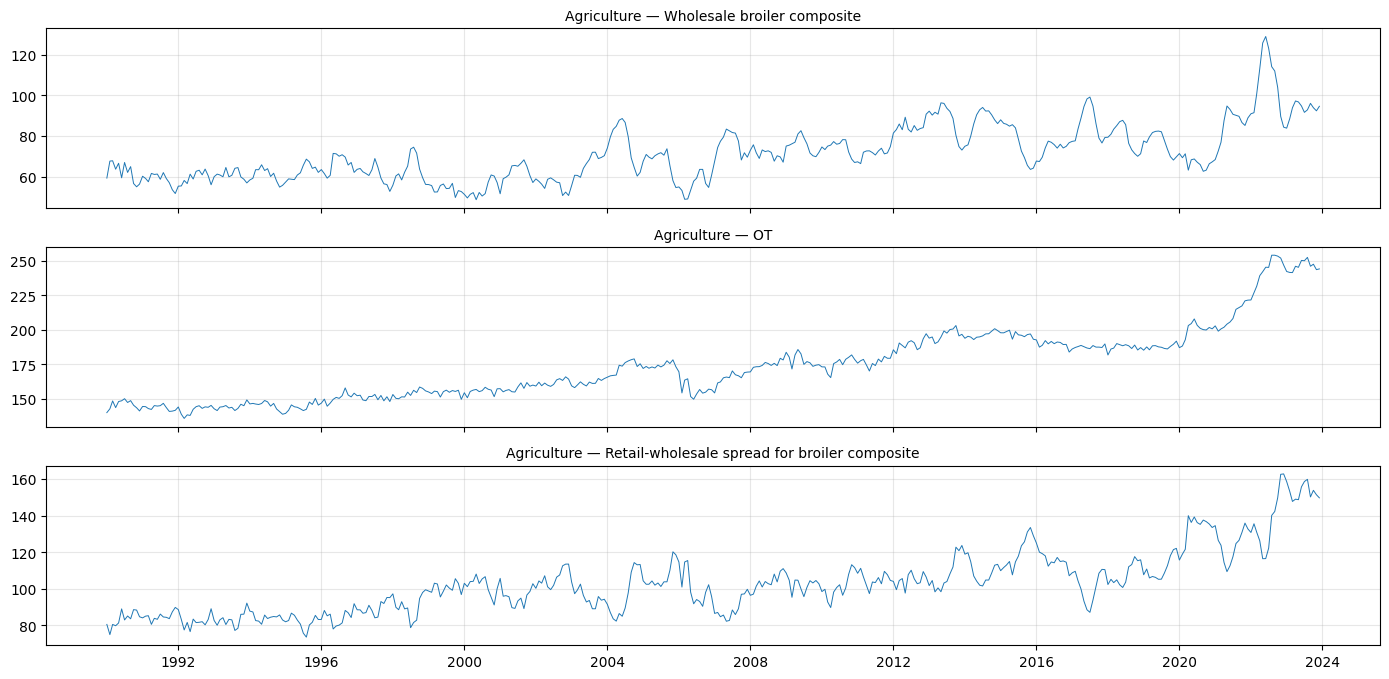

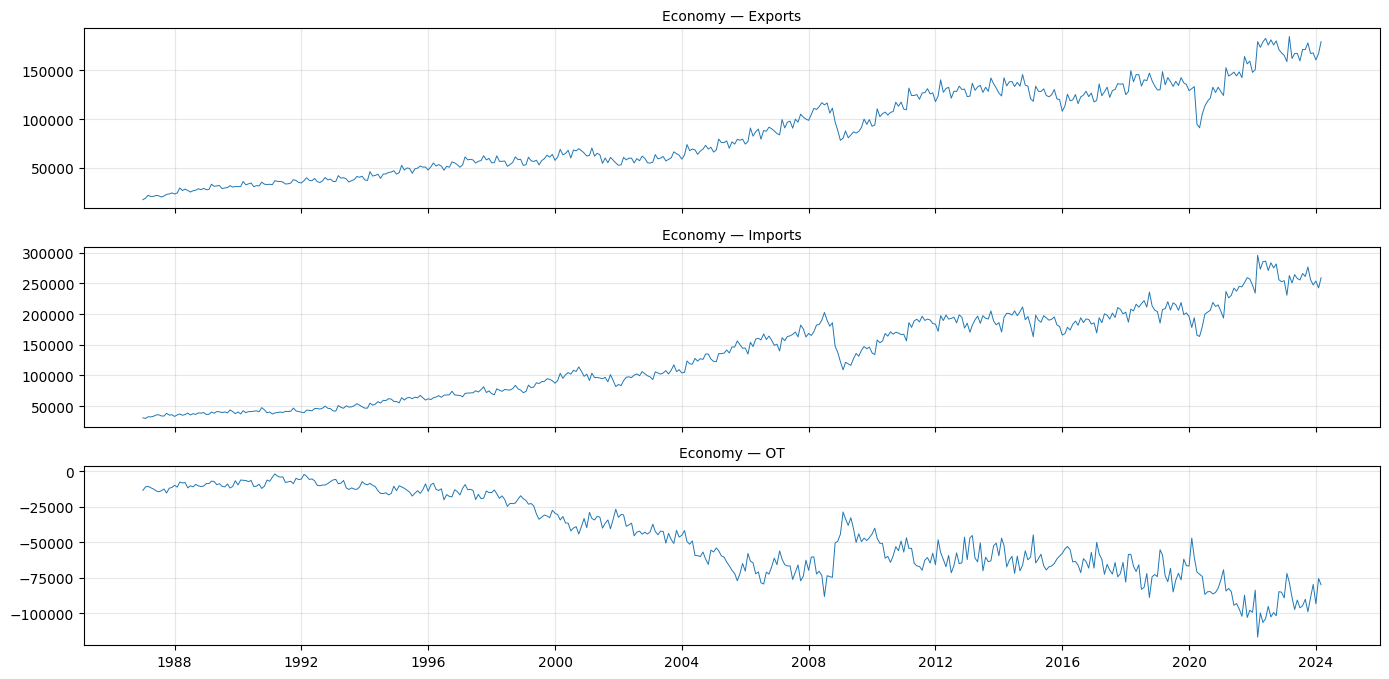

In [5]:
for d in ['Agriculture', 'Economy']:
    df = dfs[d]
    vcs = var_cols(df)
    n = len(vcs)
    fig, axes = plt.subplots(n, 1, figsize=(14, 2.3 * n), sharex=True)
    if n == 1:
        axes = [axes]
    for ax, c in zip(axes, vcs):
        ax.plot(df.date, df[c], linewidth=0.7)
        ax.set_title(f'{d} — {c}', fontsize=10)
        ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

## 4. OT 결측 패턴

OT는 target이라 결측이 있으면 그 row는 평가/학습에서 제외해야 함.
다변량 도메인(Agriculture, Economy)은 보조 변수의 결측도 함께 확인.

In [6]:
print('=== OT 결측 ===')
for d, df in dfs.items():
    n = int(df['OT'].isna().sum())
    if n == 0:
        print(f'{d:12s}: OK (결측 없음)')
    else:
        bad_dates = df.loc[df['OT'].isna(), 'date']
        print(f'{d:12s}: {n}개 결측 ({bad_dates.min().date()} ~ {bad_dates.max().date()})')

print()
print('=== 보조 변수 결측 (Agriculture, Economy) ===')
for d in ['Agriculture', 'Economy']:
    df = dfs[d]
    for c in var_cols(df):
        if c == 'OT':
            continue
        n = int(df[c].isna().sum())
        if n > 0:
            first_valid = df.loc[df[c].notna(), 'date'].min().date()
            print(f'{d} / {c:50s}: {n:3d}개 결측 (첫 유효치 {first_valid})')

=== OT 결측 ===
Agriculture : OK (결측 없음)
Economy     : OK (결측 없음)
Security    : OK (결측 없음)
SocialGood  : OK (결측 없음)
Traffic     : OK (결측 없음)

=== 보조 변수 결측 (Agriculture, Economy) ===


## 5. 텍스트 Length 분포 (월별 통합 후)

`No information` 월은 제외. report와 search 각각 char 길이 히스토그램.

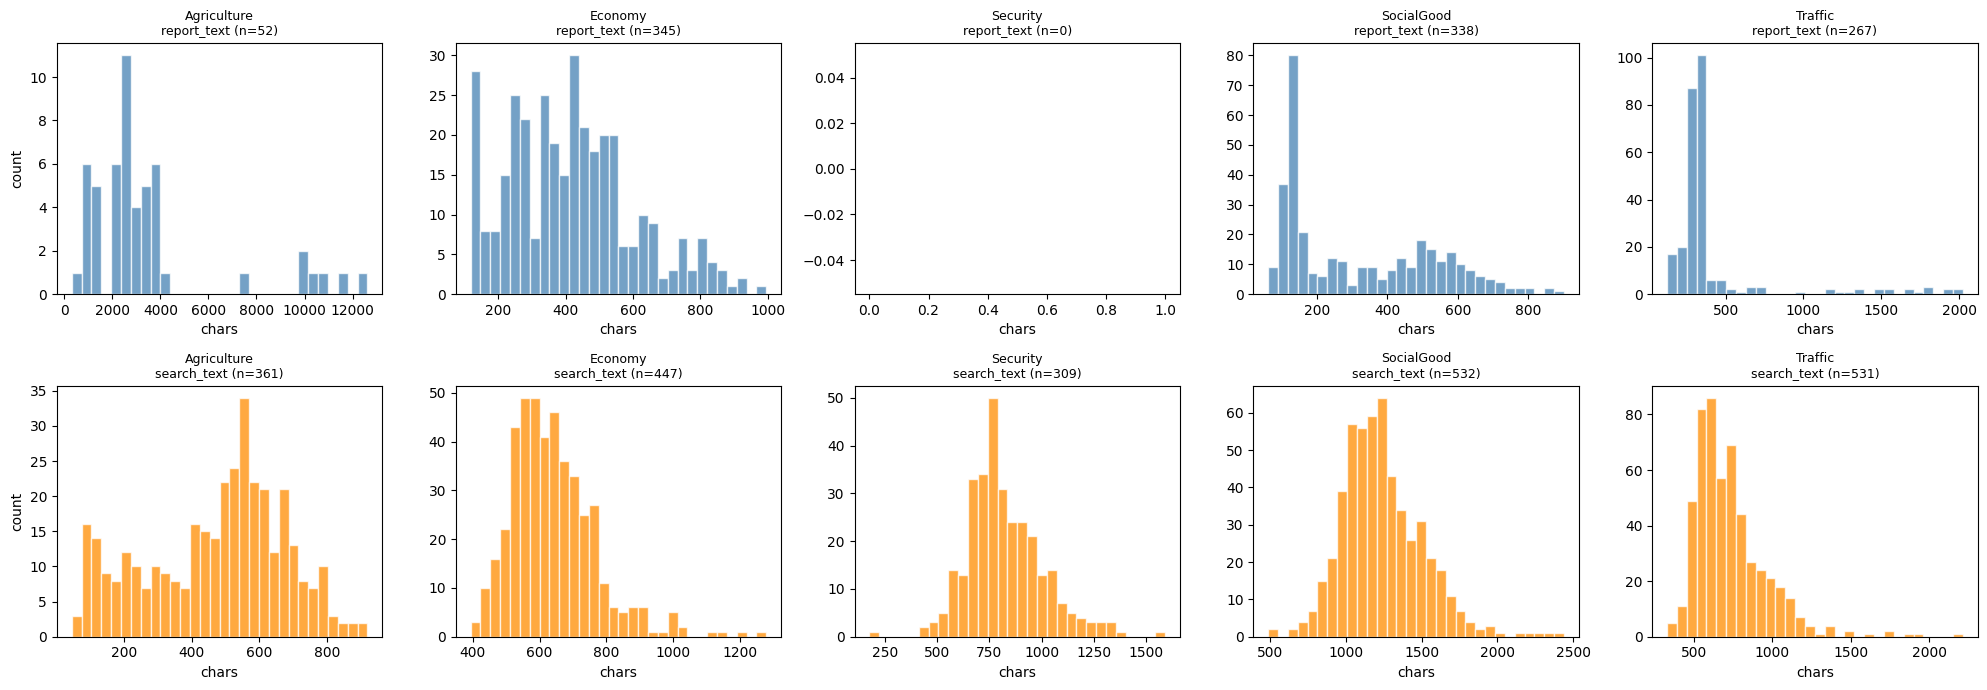

=== 텍스트 길이 통계 (chars, No-info 제외) ===


,domain,source,n,mean,p50,p95,max
0,Agriculture,report_text,52,3510,2623,10685,12619
1,Agriculture,search_text,361,469,512,774,919
2,Economy,report_text,345,416,411,786,996
3,Economy,search_text,447,640,622,879,1279
4,Security,search_text,309,824,789,1151,1590
5,SocialGood,report_text,338,320,252,679,902
6,SocialGood,search_text,532,1239,1210,1675,2438
7,Traffic,report_text,267,411,319,1427,2023
8,Traffic,search_text,531,728,677,1133,2213


In [7]:
fig, axes = plt.subplots(2, 5, figsize=(20, 7))
for col_idx, d in enumerate(DOMAINS):
    df = dfs[d]
    for row_idx, src in enumerate(['report_text', 'search_text']):
        ax = axes[row_idx, col_idx]
        valid = df.loc[df[src] != 'No information', src]
        lengths = valid.str.len()
        color = 'steelblue' if src == 'report_text' else 'darkorange'
        ax.hist(lengths, bins=30, color=color, alpha=0.75, edgecolor='white')
        ax.set_title(f'{d}\n{src} (n={len(valid)})', fontsize=9)
        ax.set_xlabel('chars')
        if col_idx == 0:
            ax.set_ylabel('count')
plt.tight_layout()
plt.show()

print('=== 텍스트 길이 통계 (chars, No-info 제외) ===')
stats = []
for d in DOMAINS:
    df = dfs[d]
    for src in ['report_text', 'search_text']:
        valid = df.loc[df[src] != 'No information', src]
        if len(valid) == 0:
            continue
        L = valid.str.len()
        stats.append({
            'domain': d, 'source': src, 'n': len(valid),
            'mean': int(L.mean()), 'p50': int(L.median()),
            'p95': int(L.quantile(0.95)), 'max': int(L.max()),
        })
pd.DataFrame(stats)

## 6. 텍스트 가용성의 시간 변화

월별로 `No information` 여부를 0/1로 보고 12-month rolling mean.
1에 가까울수록 그 시기에 텍스트가 잘 있었다는 뜻.

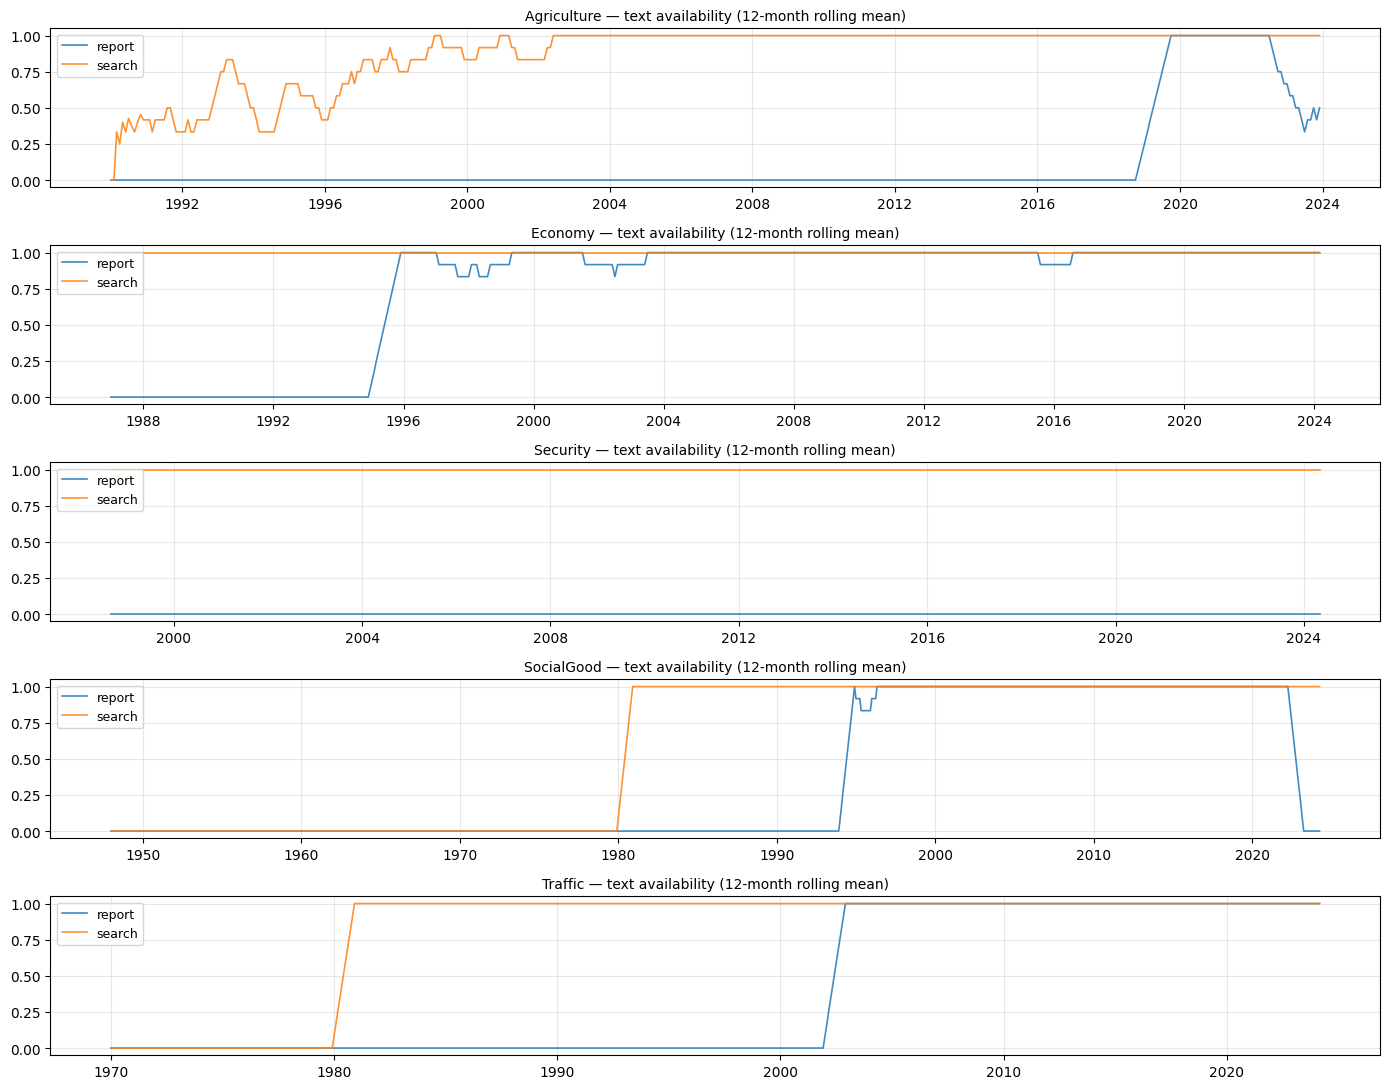

In [8]:
fig, axes = plt.subplots(5, 1, figsize=(14, 11), sharex=False)
for ax, (d, df) in zip(axes, dfs.items()):
    report_has = (df.report_text != 'No information').astype(int)
    search_has = (df.search_text != 'No information').astype(int)
    win = 12
    ax.plot(df.date, report_has.rolling(win, min_periods=1).mean(),
            label='report', alpha=0.85, linewidth=1.2)
    ax.plot(df.date, search_has.rolling(win, min_periods=1).mean(),
            label='search', alpha=0.85, linewidth=1.2)
    ax.set_title(f'{d} — text availability (12-month rolling mean)', fontsize=10)
    ax.set_ylim(-0.05, 1.05)
    ax.legend(loc='upper left', fontsize=9)
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Cross-domain OT 비교 (z-score normalized)

도메인별 OT를 z-score로 정규화 후 동일 axis에 overlay.
공통 시기(2000년 이후)에 도메인 간 패턴 유사도를 눈으로 확인 가능.
Phase 2에서 어느 도메인 페어로 파일럿할지 직관 얻기.

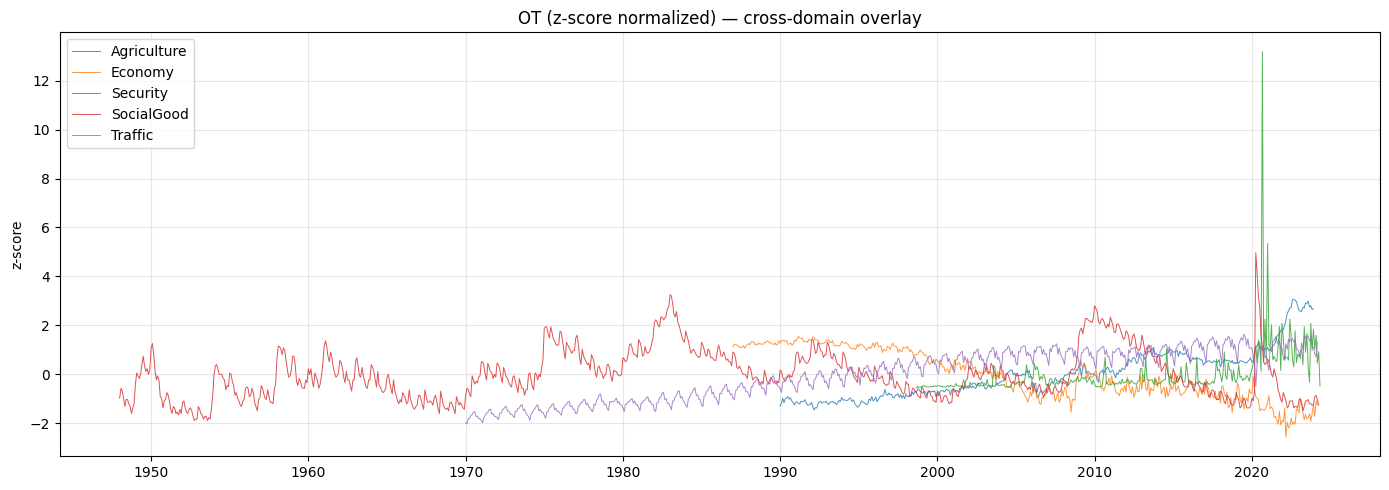

In [9]:
fig, ax = plt.subplots(figsize=(14, 5))
for d, df in dfs.items():
    ot = df['OT'].dropna()
    z = (ot - ot.mean()) / ot.std()
    ax.plot(df.loc[ot.index, 'date'], z, label=d, linewidth=0.7, alpha=0.8)
ax.set_title('OT (z-score normalized) — cross-domain overlay')
ax.set_ylabel('z-score')
ax.legend(loc='upper left')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 시사점 (Phase 2 파일럿 준비)

- **공통 시기**: Security가 가장 짧음 (1998-09 시작) → cross-domain 평가는 1998-09 이후 기간이 자연스러운 후보
- **다변량 vs 단변량**: Agriculture/Economy만 다변량. 베이스라인 호환성 위해 단변량(OT)만 쓰는 평가도 고려 필요
- **텍스트 sparsity 편차**: report는 도메인별 6% ~ 90% (Agriculture 90%, Security 6%). 모델이 텍스트 정보에 얼마나 의존 가능한지 도메인별로 다름 → cross-domain transfer 시 sparsity gap이 noise 요인
- **OT 결측**: 위 결측 셀 결과 참고

다음 단계: Phase 2 파일럿. 베이스라인 PatchTST + MM-TSFlib, LODO 페어 1쌍부터.